## Calibrate
This code is a replacement for GNBF_2_calibrate_from_Xtlvecs

In [2]:
# Generic imports
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt
import PIL
import f90nml

# Reloading
from importlib import reload

# Local imports
import sys
sys.path.append('../')
import imagestuff as ims
from imagestuff import ExtlvecxAngleManager
import local as ims2

CUDA not available.


In [3]:
%matplotlib widget

### Getting parameters for the response functions

SEMimages/case1.0-A.bmp
SEMimages/case1.0-B.bmp
SEMimages/case1.0-C.bmp
SEMimages/case1.0-D.bmp
nboxes = 3


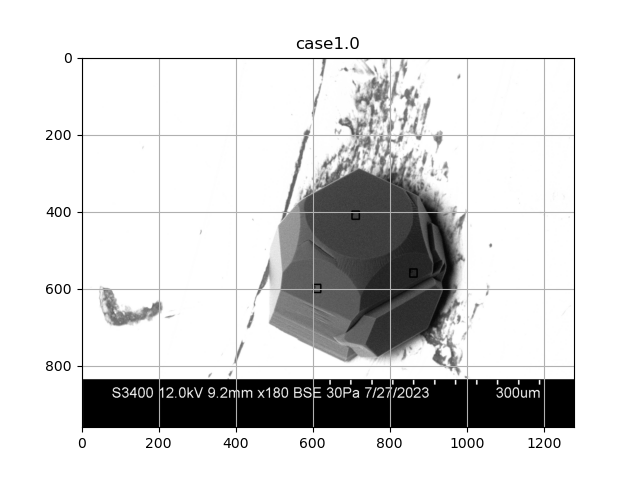

In [5]:
# For development
reload(ims2)

# Open up a figure and set up the drawing function
imageroot = 'case1.0'
dx,dy,cA,cB,cC,cD,Filename = ims.getc2('', 'SEMimages/', imageroot,'A')
im = PIL.Image.open(Filename)
draw = PIL.ImageDraw.Draw(im)
plt.figure()

# Specify the calibration boxes
nx1list,nx2list,ny1list,ny2list = ims2.get_box_lists('Boxes.nml',draw)

# Setup the angle manager with default Euler angles
alpha_default = -170
beta_default = 28
gamma_default = 12
xorigin = 712
yorigin = 684
angleManager = ExtlvecxAngleManager(xorigin,yorigin,alpha_default, beta_default, gamma_default)
angleManager.calculate_starts()
angleManager.construct_rotation_matrices()

# Get the nvecs
cvecdir = 'pointingdown' # Alternative is 'pointingup' 
boxa= 'pyramidal' # Alternative is 'prismatic'
boxb= 'pyramidal' # Alternative is 'prismatic'
navec, nbvec, ndvec = ims2.get_nvecs(angleManager, draw, cvecdir, boxa, boxb, nx1list, ny1list)

# Finish up
plt.title(imageroot)
plt.imshow(im,cmap = 'Greys_r', vmin = 0,vmax = 255)
plt.grid(True)

### Fine-tuning the Euler angles

In [12]:
reload(ims2)
ims2.get_box_lists('Boxes.nml',draw)
desired_facet_angles = [[0,1,62.0],[0,2,62.0]]

angle_number = 5
angle_range = 4
alpha_min = np.max([-180, alpha_default-angle_range]); alpha_max = np.min([180,alpha_default+angle_range]); print(alpha_min,alpha_max)
beta_min = np.max([0, beta_default-angle_range]); beta_max = np.min([180, beta_default+angle_range]); print (beta_min,beta_max)
gamma_min = np.max([-180, gamma_default-angle_range]); gamma_max = np.min([180,gamma_default+angle_range]); print(gamma_min,gamma_max)
least_error = 1e5
for alpha in np.linspace(alpha_min,alpha_max,angle_number):
    for beta in np.linspace(beta_min,beta_max,angle_number):
        for gamma in np.linspace(gamma_min,gamma_max,angle_number):
            angleManager.alpha   = alpha
            angleManager.beta    = beta
            angleManager.gamma   = gamma
            angleManager.update()
            navec, nbvec, ndvec = ims2.get_nvecs(\
                angleManager, draw, cvecdir, boxa, boxb, nx1list, ny1list)
            pA, pB, pC, pD, response_function_error = ims2.response_function(\
                navec,nbvec,ndvec,cA,cB,cC,cD,nx1list,nx2list,ny1list,ny2list,imageroot)
            surfaces, sfunctions, retrieval_error = ims2.retrieve_segments(\
                pA, pB, pC, pD, cA, cB, cC, cD, nx1list, nx2list, ny1list, ny2list, \
                imageroot, dx=dx, dy=dy, overlapping=False, desired_facet_angles=desired_facet_angles)
            if retrieval_error < least_error:
                print('Picking up a new least error ...')
                alpha_best = alpha
                beta_best = beta
                gamma_best = gamma
                pA_best = pA
                pB_best = pB
                pC_best = pC
                pD_best = pD
                least_error = retrieval_error
                print(alpha_best,beta_best,gamma_best,retrieval_error)
print('best alpha, beta, gamma, pA, and error = ', alpha_best, beta_best, gamma_best, pA_best, least_error)

# angleManager.alpha   = alpha_best
# angleManager.beta    = beta_best
# angleManager.gamma   = gamma_best
# angleManager.update()
# navec, nbvec, ndvec = ims2.get_nvecs(angleManager, draw, cvecdir, boxa, boxb, nx1list, ny1list)
# error = ims2.response_function(navec,nbvec,ndvec,cA,cB,cC,cD,nx1list,nx2list,ny1list,ny2list,imageroot,graphics=True)
# print(error)

# im = PIL.Image.open(Filename)
# draw = PIL.ImageDraw.Draw(im)
# plt.figure()

# ims2.get_box_lists('Boxes.nml',draw)

# angleManager.alpha   = alpha_best
# angleManager.beta    = beta_best
# angleManager.gamma   = gamma_best
# angleManager.update()
# navec, nbvec, ndvec = ims2.get_nvecs(angleManager, draw, cvecdir, boxa, boxb, nx1list, ny1list)

# Finish up
plt.title(imageroot)
plt.imshow(im,cmap = 'Greys_r', vmin = 0,vmax = 255)
plt.grid(True)

nboxes = 3
-174 -166
24 32
8 16
nsegments  3
Std deviation in input signal is 5.0
Std deviation in a priori is 15.0

Segment: 0 ( 1 of 3 )
for 600 590
Observed intensities (detector B):
mean, max, min = 44.3925 60.0 31.0
<diff>, std(diff), di2 = 4.1832467904804504 21.104515620052847 25779.70109679602
<diff>, std(diff), di2 = 4.563594312112972 6.152672937685099 665.2276897884226
<diff>, std(diff), di2 = 4.431691673822524 5.32216291620803 11.149651748366292
<diff>, std(diff), di2 = 4.4073103315340845 5.32412216885732 0.0731192861708512

Segment: 1 ( 2 of 3 )
for 850 550
Observed intensities (detector B):
mean, max, min = 50.51 71.0 35.0
<diff>, std(diff), di2 = 10.110121790480449 31.573494725441524 62046.19748227694
<diff>, std(diff), di2 = 7.2963996294392315 10.382166616588432 4539.24207690219
<diff>, std(diff), di2 = 5.913695258509235 7.696752967432425 582.5637135275088
<diff>, std(diff), di2 = 5.212525226987268 7.571843181473089 71.16720525379547
<diff>, std(diff), di2 = 4.93016774862

### Retrieve

In [15]:
# surf_xgridtot, surf_ygridtot, surf_zgridtot = ims2.retrieve_segments(\
reload(ims2)
surfaces, sfunctions, error = ims2.retrieve_segments(\
    pA, pB, pC, pD, cA, cB, cC, cD, nx1list, nx2list, ny1list, ny2list, imageroot, dx=dx, dy=dy, overlapping=False)

nsegments  3
Std deviation in input signal is 5.0
Std deviation in a priori is 15.0

Segment: 0 ( 1 of 3 )
for 600 590
Observed intensities (detector B):
mean, max, min = 44.3925 60.0 31.0
<diff>, std(diff), di2 = 4.101017382115081 20.274123656605106 23505.638827335697
<diff>, std(diff), di2 = 4.5281856057715455 6.1385388413495505 513.1539713865495
<diff>, std(diff), di2 = 4.43262162789882 5.500517055169694 6.183657538897228

Segment: 1 ( 2 of 3 )
for 850 550
Observed intensities (detector B):
mean, max, min = 50.51 71.0 35.0
<diff>, std(diff), di2 = 10.02789238211508 27.944674385820484 48028.335812423014
<diff>, std(diff), di2 = 7.524527096926973 9.103872271499489 2564.234617030046
<diff>, std(diff), di2 = 6.489155797811647 7.573937684814473 190.61738721727062
<diff>, std(diff), di2 = 6.121145409313987 7.659043553162183 10.597726642667114
<diff>, std(diff), di2 = 6.037332815031631 7.710346873134083 0.7593396001501
Noverlap = 0

Segment: 2 ( 3 of 3 )
for 700 400
Observed intensities (d

In [17]:
error

0

### Saving the calibration

In [10]:
Calibrationfile = 'Calibration.nml'
cfile = open(Calibrationfile,'w')
cfile.write('&Calibration\n')
cfile.write('   '+'pA = '+str(pA[0])+',  '+str(pA[1])+'\n')
cfile.write('   '+'pB = '+str(pB[0])+',  '+str(pB[1])+'\n')
cfile.write('   '+'pC = '+str(pC[0])+',  '+str(pC[1])+'\n')
cfile.write('   '+'pD = '+str(pD[0])+',  '+str(pD[1])+'\n')
cfile.write('/ \n')
cfile.close()

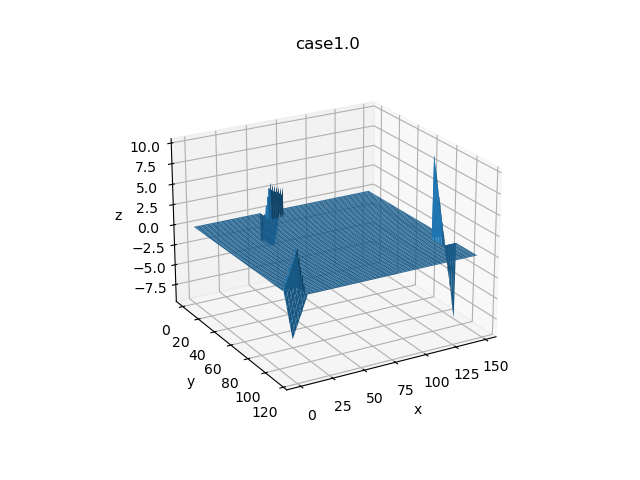

In [27]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.invert_yaxis() # invert y axis (this fixes the right-hand-oriented vs left-hand-oriented system)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title(imageroot)
ax.view_init(azim=-120,elev=22)
ax.plot_surface(surfaces[0], surfaces[1], surfaces[2], rstride=3 ,cstride=3)